In [1]:
from probjax.core.utils import BaseInterpreter, BaseRules
from probjax.core.random_variable import rv, rv_p

from probjax.distributions import Normal

import jax 
from jax.core import Literal
import jax.numpy as jnp
import jax.random as jrandom

import networkx as nx


No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [2]:
def test(key):
    return jax.random.normal(key, ())

In [14]:
# Probabilistic program
def f(key):
    key1, key2 = jrandom.split(key)
    Z = rv(Normal(jnp.array([0.]),jnp.array([1.])), "Z")
    Y = Z(key1)**2
    X = rv(Normal(Y,jnp.array([1.])), "X")
    return X(key2)

In [15]:
jaxpr = jax.make_jaxpr(f)(jrandom.PRNGKey(0))

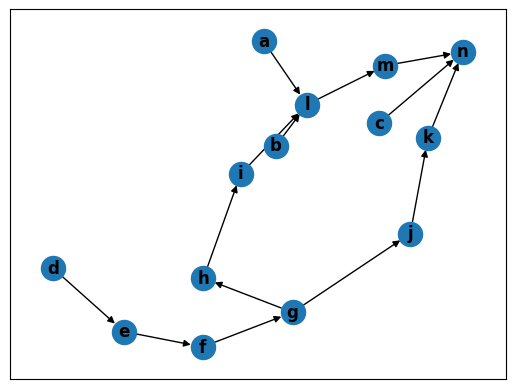

In [16]:
nodes = set()
node_attributes = dict()
edges = set()
edge_attributes = dict()

for node in jaxpr.jaxpr.constvars:
    name = str(node)
    nodes.add(name)
    node_attributes[name] = {"var": node}

for node in jaxpr.jaxpr.invars:
    name = str(node)
    nodes.add(name)
    node_attributes[name] = {"var": node}

for node in jaxpr.jaxpr.outvars:
    name = str(node)
    nodes.add(name)
    node_attributes[name] = {"var": node}

for eqn in jaxpr.jaxpr.eqns:
    invars = eqn.invars
    outvars = eqn.outvars
    
    for node in eqn.outvars:
        name = str(node)
        nodes.add(name)
        if not name in node_attributes:
            node_attributes[name] = {"var": node}

    for node1 in eqn.invars:
        name1 = str(node1)
        nodes.add(name1)
        if not name1 in node_attributes:
            node_attributes[name1] = {"var": node1}
        for node2 in eqn.outvars:
            name2 = str(node2)
            edges.add((name1,name2))
            edge_attributes[(name1,name2)] = {"eqn": eqn}

G = nx.DiGraph(edges)
nx.set_node_attributes(G, node_attributes)
nx.set_edge_attributes(G, edge_attributes)
nx.draw_networkx(G, with_labels=True, font_weight='bold')

In [17]:

import jax
from jax import core
from graphviz import Digraph
import itertools

styles = {
  'const': dict(style='', color='goldenrod1'),
  'invar': dict(color='mediumspringgreen', style='filled'),
  'outvar': dict(style='filled,dashed', fillcolor='indianred1', color='black'),
  'op_node': dict(shape='box', color='lightskyblue', style='filled'),
  'intermediate': dict(style='filled', color='cornflowerblue')
}


def _jaxpr_graph(jaxpr):
  id_names = (f'id{id}' for id in itertools.count())
  graph = Digraph(engine='dot')
  graph.attr(size='6,10!')
  for v in jaxpr.constvars:
    graph.node(str(v), core.raise_to_shaped(v.aval).str_short(), styles['const'])
  for v in jaxpr.invars:
    graph.node(str(v), v.aval.str_short(), styles['invar'])
  for eqn in jaxpr.eqns:
    for v in eqn.invars:
      if isinstance(v, core.Literal):
        graph.node(str(id(v.val)), core.raise_to_shaped(core.get_aval(v.val)).str_short(),
                   styles['const'])
    if eqn.primitive.multiple_results:
      id_name = next(id_names)
      graph.node(id_name, str(eqn.primitive), styles['op_node'])
      for v in eqn.invars:
        graph.edge(str(id(v.val) if isinstance(v, core.Literal) else v), id_name)
      for v in eqn.outvars:
        graph.node(str(v), v.aval.str_short(), styles['intermediate'])
        graph.edge(id_name, str(v))
    else:
      outv, = eqn.outvars
      graph.node(str(outv), str(eqn.primitive), styles['op_node'])
      for v in eqn.invars:
        graph.edge(str(id(v.val) if isinstance(v, core.Literal) else v), str(outv))
  for i, v in enumerate(jaxpr.outvars):
    outv = 'out_'+str(i)
    graph.node(outv, outv, styles['outvar'])
    graph.edge(str(v), outv)
  return graph

jaxpr_graph = _jaxpr_graph(jaxpr.jaxpr)

In [21]:
from jax._src.lax.control_flow.common import (
    _abstractify,
)
type(_abstractify(jrandom.PRNGKey(0)))

jax._src.core.ShapedArray

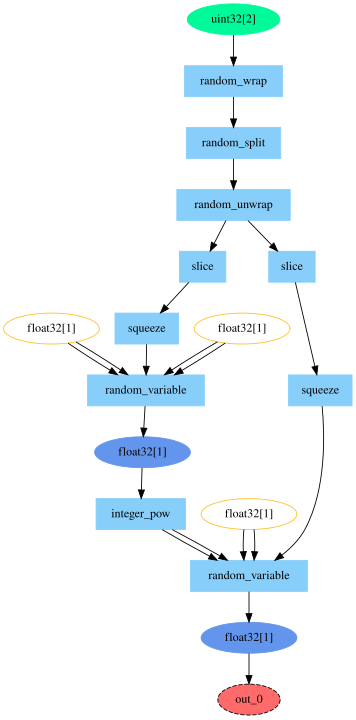

In [26]:
jaxpr_graph

In [62]:
G_sub.edges[("d", "m")]

KeyError: 'Key m not found'

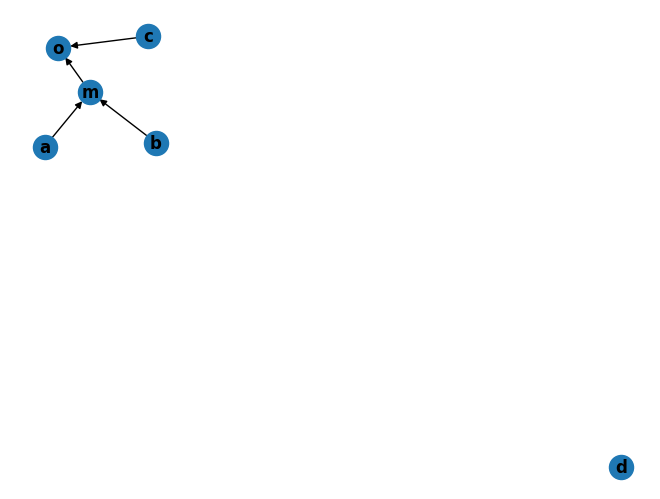

In [63]:
G_sub = nx.subgraph(G, ["a", "b", "c", "m", "o", "d"])
G_sub.nodes
nx.draw(G_sub, with_labels=True, font_weight='bold')

In [7]:
jaxpr = jax.make_jaxpr(f)(jrandom.PRNGKey(0))
constant_nodes = [var for var in jaxpr.jaxpr.constvars]
constants_attributes = [{"value": val } for val in jaxpr.consts]
random_variables = [eqn for eqn in jaxpr.jaxpr.eqns if eqn.primitive is rv_p]
random_variable_nodes = []
random_variable_data = []
vars_to_trace = []
for n in random_variables:
    name = n.params.pop("name")
    node_data = n.params
    node_data["in_vars"] = n.invars
    node_data["out_vars"] = n.outvars
    random_variable_nodes.append(name)
    random_variable_data.append(node_data)

In [8]:
random_variables[0].invars

[b, a, b, a, i]

In [9]:
G = nx.DiGraph()

for n, d in zip(random_variable_nodes, random_variable_data):
    G.add_node(n, **d)

for n, d in zip(constant_nodes, constants_attributes):
    G.add_node(n, **d)

G.nodes

NodeView(('Z', 'X', a, b, c))